In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

import torch.nn.functional as F

In [3]:
class CLAHE(object):

    def __init__(self, clip_limit=2.0, tile_grid_size=(8,8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, img):

        img = np.array(img)

        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        clahe = cv2.createCLAHE(
            clipLimit=self.clip_limit,
            tileGridSize=self.tile_grid_size
        )

        img = clahe.apply(img)

        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        return Image.fromarray(img)

In [4]:
train_transform = transforms.Compose([

    CLAHE(),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [5]:
val_transform = transforms.Compose([

    CLAHE(),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [6]:
train_dataset = ImageFolder(
    "../archive/chest_xray/train",
    transform=train_transform
)

val_dataset = ImageFolder(
    "../archive/chest_xray/val",
    transform=val_transform
)

test_dataset = ImageFolder(
    "../archive/chest_xray/test",
    transform=val_transform
)

In [7]:
import torch
import torch.nn as nn

from torchvision.models import vit_b_16, ViT_B_16_Weights

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [9]:
weights = ViT_B_16_Weights.DEFAULT

model = vit_b_16(weights=weights)

In [10]:
num_classes = len(train_dataset.classes)

print(num_classes)

2


In [11]:
in_features = model.heads.head.in_features

model.heads.head = nn.Linear(
    in_features,
    num_classes
)

In [12]:
num_classes = len(train_dataset.classes)

print(num_classes)

2


In [13]:
in_features = model.heads.head.in_features

model.heads.head = nn.Linear(
    in_features,
    num_classes
)

In [28]:
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

In [15]:
def imshow(img):

    img = img.numpy().transpose((1,2,0))

    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])

    img = std * img + mean
    img = np.clip(img,0,1)

    plt.imshow(img)

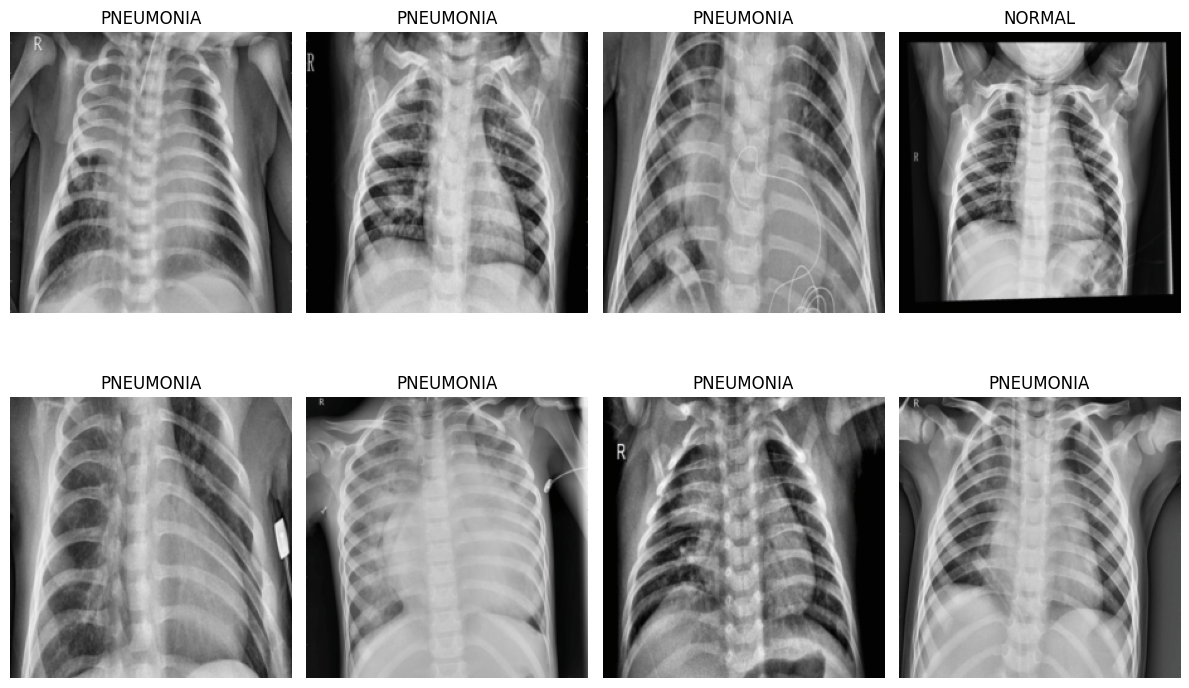

In [16]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12,8))

for i in range(8):

    plt.subplot(2,4,i+1)

    imshow(images[i])

    plt.title(train_dataset.classes[labels[i]])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
from torch.utils.data import WeightedRandomSampler
from collections import Counter
import numpy as np

In [18]:
train_labels = [label for _, label in train_dataset.samples]

print(Counter(train_labels))

Counter({1: 3875, 0: 1341})


In [19]:
class_counts = np.bincount(train_labels)

class_weights = 1.0 / class_counts

sample_weights = class_weights[train_labels]

In [20]:
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [21]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler,
    num_workers=0,
    pin_memory=True
)

In [22]:
images, labels = next(iter(train_loader))

print(labels)

d:\ai-based-medical-imaging\.venv\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


tensor([1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1])


In [26]:
weights = torch.load("../models/best_vit_model.pth", weights_only=True, map_location=torch.device('cpu'))

In [27]:
model.load_state_dict(weights)
model.eval()

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine

In [29]:
criterion = nn.CrossEntropyLoss()

In [30]:
test_loss = 0

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        probabilities = F.softmax(outputs, dim=1)

        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())

        all_predictions.extend(predictions.cpu().numpy())

        all_probabilities.extend(probabilities.cpu().numpy())

In [31]:
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

test_loss /= len(test_loader)

In [32]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

Test Loss     : 0.3980
Test Accuracy : 0.8574


In [33]:
precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

Precision : 0.8720252069275451
Recall    : 0.8573717948717948
F1 Score  : 0.8502953091842641


In [34]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes
    )
)

              precision    recall  f1-score   support

      NORMAL       0.95      0.65      0.77       234
   PNEUMONIA       0.83      0.98      0.90       390

    accuracy                           0.86       624
   macro avg       0.89      0.82      0.84       624
weighted avg       0.87      0.86      0.85       624



<Figure size 800x800 with 0 Axes>

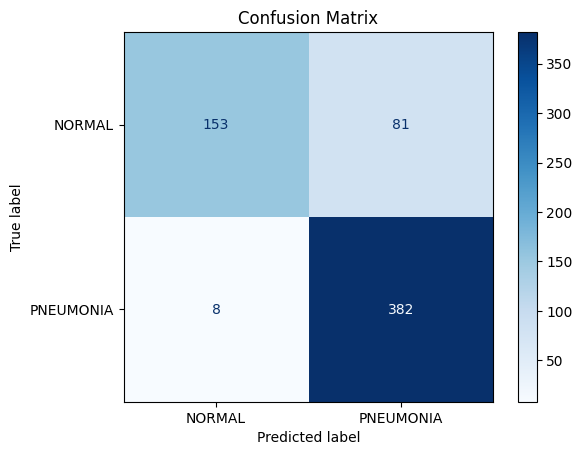

In [35]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

plt.figure(figsize=(8,8))

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")

plt.show()